<a href="https://colab.research.google.com/github/sRoy2068/CustomerSegmentationAnalysis/blob/main/Bank_clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import silhouette_score
from mpl_toolkits.mplot3d import Axes3D

In [2]:
# importing dataset

customer_df = pd.read_csv('/content/drive/MyDrive/Bank Customer Analysis/Bank_customer_cleaned.csv')
customer_df.head()

,CustomerId,Gender,Age,Geo_loc,CreditScore,EstimatedSalary,Balance,NumOfProducts,HasCrCard,Tenure,IsActiveMember,Exited
0,15592531,Male,50,France,822,10062.80,0.0,2,Yes,7,Yes,0
1,15724944,Male,34,France,663,180427.24,0.0,2,Yes,7,Yes,0
2,15598493,Male,50,France,656,72143.44,0.0,2,Yes,7,Yes,0
3,15747542,Male,52,France,605,173952.50,0.0,2,Yes,7,Yes,0
4,15721935,Male,25,France,521,157878.67,0.0,2,Yes,7,Yes,0


In [3]:
customer_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9997 entries, 0 to 9996
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerId       9997 non-null   int64  
 1   Gender           9997 non-null   object 
 2   Age              9997 non-null   int64  
 3   Geo_loc          9997 non-null   object 
 4   CreditScore      9997 non-null   int64  
 5   EstimatedSalary  9997 non-null   float64
 6   Balance          9997 non-null   float64
 7   NumOfProducts    9997 non-null   int64  
 8   HasCrCard        9997 non-null   object 
 9   Tenure           9997 non-null   int64  
 10  IsActiveMember   9997 non-null   object 
 11  Exited           9997 non-null   int64  
dtypes: float64(2), int64(6), object(4)
memory usage: 937.3+ KB


In [4]:
binary_cols = ["HasCrCard", "IsActiveMember"]


for col in binary_cols:
    print(customer_df[col].value_counts())

HasCrCard
Yes    5149
No     4848
Name: count, dtype: int64
IsActiveMember
Yes    5149
No     4848
Name: count, dtype: int64


In [5]:
# converting to correct numerical type

for col in binary_cols:
    customer_df[col] = (
        customer_df[col]
        .astype(str)
        .str.strip()
        .str.title()
        .map({"Yes": 1, "No": 0})
    )

customer_df[binary_cols].head()

,HasCrCard,IsActiveMember
0,1,1
1,1,1
2,1,1
3,1,1
4,1,1


In [6]:
# converting to int type
customer_df[binary_cols] = customer_df[binary_cols].astype(int)

In [7]:
customer_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9997 entries, 0 to 9996
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerId       9997 non-null   int64  
 1   Gender           9997 non-null   object 
 2   Age              9997 non-null   int64  
 3   Geo_loc          9997 non-null   object 
 4   CreditScore      9997 non-null   int64  
 5   EstimatedSalary  9997 non-null   float64
 6   Balance          9997 non-null   float64
 7   NumOfProducts    9997 non-null   int64  
 8   HasCrCard        9997 non-null   int64  
 9   Tenure           9997 non-null   int64  
 10  IsActiveMember   9997 non-null   int64  
 11  Exited           9997 non-null   int64  
dtypes: float64(2), int64(8), object(2)
memory usage: 937.3+ KB


In [8]:
# one hot encoding categorical data

categorical_cols = ["Geo_loc", "Gender"]

for col in categorical_cols:
  print(customer_df[col].value_counts())

Geo_loc
France     5013
Germany    2508
Spain      2476
Name: count, dtype: int64
Gender
Male      5456
Female    4541
Name: count, dtype: int64


In [9]:
# create a copy of the original dataset
customer_df_encoded = customer_df.copy()


# binary encoding gender column

customer_df_encoded["Gender"] = (
    customer_df_encoded["Gender"]
    .astype(str)
    .str.strip()
    .str.title()
    .map({"Male": 1, "Female": 0})
)

customer_df_encoded["Gender"] = customer_df_encoded["Gender"].astype(int)

In [10]:
# one hot encoding the geography column
customer_df_encoded = pd.get_dummies(
    customer_df_encoded,
    columns=["Geo_loc"],
    drop_first=False,
    dtype=int
)

In [11]:
# previewing the encoded dataset
customer_df_encoded.head()

,CustomerId,Gender,Age,CreditScore,EstimatedSalary,Balance,NumOfProducts,HasCrCard,Tenure,IsActiveMember,Exited,Geo_loc_France,Geo_loc_Germany,Geo_loc_Spain
0,15592531,1,50,822,10062.80,0.0,2,1,7,1,0,1,0,0
1,15724944,1,34,663,180427.24,0.0,2,1,7,1,0,1,0,0
2,15598493,1,50,656,72143.44,0.0,2,1,7,1,0,1,0,0
3,15747542,1,52,605,173952.50,0.0,2,1,7,1,0,1,0,0
4,15721935,1,25,521,157878.67,0.0,2,1,7,1,0,1,0,0


--- CreditScore Analysis ---
Normal range: 9982 (99.85%)
Outliers: 15 (0.15%)


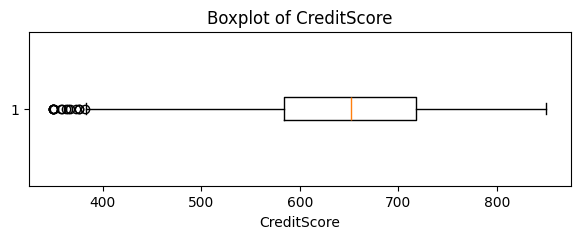



--- Age Analysis ---
Normal range: 9638 (96.41%)
Outliers: 359 (3.59%)


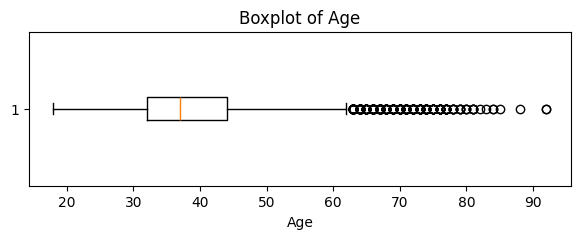



--- Tenure Analysis ---
Normal range: 9997 (100.00%)
Outliers: 0 (0.00%)


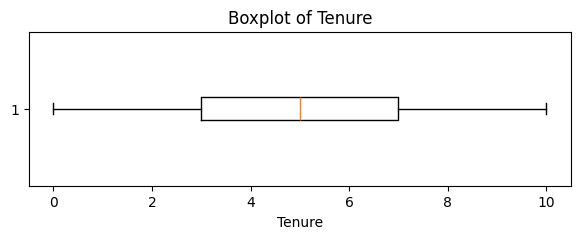



--- Balance Analysis ---
Normal range: 9997 (100.00%)
Outliers: 0 (0.00%)


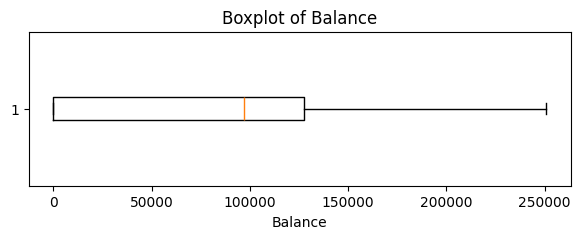



--- EstimatedSalary Analysis ---
Normal range: 9997 (100.00%)
Outliers: 0 (0.00%)


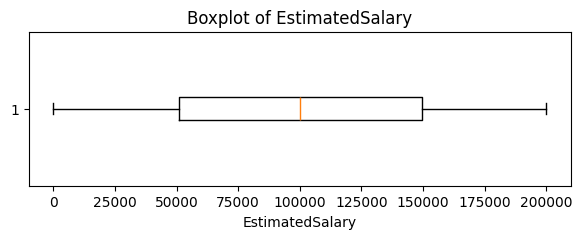



--- NumOfProducts Analysis ---
Normal range: 9937 (99.40%)
Outliers: 60 (0.60%)


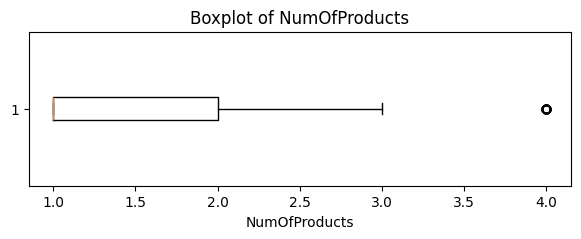

In [12]:
# outlier/skewness handling
# Columns where outliers/skewness matter most
outlier_cols = [
    "CreditScore",
    "Age",
    "Tenure",
    "Balance",
    "EstimatedSalary",
    "NumOfProducts"
]

for col in outlier_cols:
    # Calculate IQR
    Q1 = customer_df_encoded[col].quantile(0.25)
    Q3 = customer_df_encoded[col].quantile(0.75)
    IQR = Q3 - Q1

    # Define bounds
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Identify outliers
    outliers = customer_df_encoded[(customer_df_encoded[col] < lower_bound) | (customer_df_encoded[col] > upper_bound)]
    normal = customer_df_encoded[(customer_df_encoded[col] >= lower_bound) & (customer_df_encoded[col] <= upper_bound)]

    outlier_count = len(outliers)
    total_count = len(customer_df_encoded[col])
    outlier_percent = (outlier_count / total_count) * 100

    print(f"--- {col} Analysis ---")
    print(f"Normal range: {len(normal)} ({100 - outlier_percent:.2f}%)")
    print(f"Outliers: {outlier_count} ({outlier_percent:.2f}%)")

    plt.figure(figsize=(7, 2))
    plt.boxplot(customer_df_encoded[col].dropna(), vert=False)
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.show()
    print("\n")

Variables in Focus


1.   Age - values > 60 listed as outliers going till 90, showcasing real world behavior. Bank customers aged 65, 75, 85, or even 90+ are realistic.
2.   Credit Score - credit score of very few customers less than 400, aligning with real world behavior where a certain proportion of customers fall in poor credit rating
3. No of Products - Some outliers on the positive side, completely normal as in every bank there are few customers usaging high amount of products/services.



In [13]:
# creating a flag column to classify users who have balance and not
customer_df_encoded["HasBalance"] = (customer_df["Balance"] > 0).astype(int)

print(customer_df_encoded["HasBalance"].value_counts())
print(customer_df["Balance"].value_counts())

HasBalance
1    6381
0    3616
Name: count, dtype: int64
Balance
0.00         3616
130170.82       2
105473.74       2
103023.26       1
133377.80       1
             ... 
93816.70        1
129264.05       1
130700.92       1
96152.68        1
109949.05       1
Name: count, Length: 6380, dtype: int64


Standardizing Numerical Columns

Standardizing distributions of numerical columns to mean = 0 and std dev = 1 to bring features with different units and scales (creditScore, age, balance) on a single comparable scale.

In [14]:
# standardizing numerical columns

# Numerical columns to standardize
scale_cols = [
    "CreditScore",
    "Age",
    "Tenure",
    "Balance",
    "EstimatedSalary",
    "NumOfProducts"
]

# Create scaler
scaler = StandardScaler()

# Apply standardization
customer_df_encoded[scale_cols] = scaler.fit_transform(customer_df_encoded[scale_cols])

# Check result
customer_df_encoded[scale_cols].head()

,CreditScore,Age,Tenure,Balance,EstimatedSalary,NumOfProducts
0,1.773918,1.056192,0.686945,-1.225801,-1.565296,0.807443
1,0.128859,-0.469281,0.686945,-1.225801,1.396745,0.807443
2,0.056435,1.056192,0.686945,-1.225801,-0.485931,0.807443
3,-0.471225,1.246876,0.686945,-1.225801,1.284171,0.807443
4,-1.340313,-1.327360,0.686945,-1.225801,1.004704,0.807443


In [15]:
customer_df_encoded[scale_cols].describe()

,CreditScore,Age,Tenure,Balance,EstimatedSalary,NumOfProducts
count,9.997000e+03,9.997000e+03,9.997000e+03,9.997000e+03,9.997000e+03,9.997000e+03
mean,-3.226832e-16,3.056251e-16,1.002166e-16,9.097676e-17,2.835916e-16,-3.411629e-16
std,1.000050e+00,1.000050e+00,1.000050e+00,1.000050e+00,1.000050e+00,1.000050e+00
min,-3.109526e+00,-1.994754e+00,-1.733341e+00,-1.225801e+00,-1.740052e+00,-9.118340e-01
25%,-6.884970e-01,-6.599652e-01,-6.960757e-01,-1.225801e+00,-8.539839e-01,-9.118340e-01
50%,1.505008e-02,-1.832548e-01,-4.565338e-03,3.318576e-01,2.500132e-03,-9.118340e-01
75%,6.979046e-01,4.841398e-01,6.869450e-01,8.199461e-01,8.572843e-01,8.074426e-01
max,2.063614e+00,5.060560e+00,1.724211e+00,2.795385e+00,1.736916e+00,4.245996e+00


In [16]:
customer_df_encoded.head()

,CustomerId,Gender,Age,CreditScore,EstimatedSalary,Balance,NumOfProducts,HasCrCard,Tenure,IsActiveMember,Exited,Geo_loc_France,Geo_loc_Germany,Geo_loc_Spain,HasBalance
0,15592531,1,1.056192,1.773918,-1.565296,-1.225801,0.807443,1,0.686945,1,0,1,0,0,0
1,15724944,1,-0.469281,0.128859,1.396745,-1.225801,0.807443,1,0.686945,1,0,1,0,0,0
2,15598493,1,1.056192,0.056435,-0.485931,-1.225801,0.807443,1,0.686945,1,0,1,0,0,0
3,15747542,1,1.246876,-0.471225,1.284171,-1.225801,0.807443,1,0.686945,1,0,1,0,0,0
4,15721935,1,-1.327360,-1.340313,1.004704,-1.225801,0.807443,1,0.686945,1,0,1,0,0,0


In [17]:
""" Create a copy of dataset for kmeans clustering and remove non-feature columns such as
    id columns and non encoded columns """

clustering_df = customer_df_encoded.drop(columns=['CustomerId', 'Exited', 'HasCrCard'])

# Display the first few rows to confirm
display(clustering_df.head())

,Gender,Age,CreditScore,EstimatedSalary,Balance,NumOfProducts,Tenure,IsActiveMember,Geo_loc_France,Geo_loc_Germany,Geo_loc_Spain,HasBalance
0,1,1.056192,1.773918,-1.565296,-1.225801,0.807443,0.686945,1,1,0,0,0
1,1,-0.469281,0.128859,1.396745,-1.225801,0.807443,0.686945,1,1,0,0,0
2,1,1.056192,0.056435,-0.485931,-1.225801,0.807443,0.686945,1,1,0,0,0
3,1,1.246876,-0.471225,1.284171,-1.225801,0.807443,0.686945,1,1,0,0,0
4,1,-1.327360,-1.340313,1.004704,-1.225801,0.807443,0.686945,1,1,0,0,0


In [18]:
#plot inertia and sillhouette scores

# Store results
k_values = range(2, 11)
inertia_scores = []
silhouette_scores = []

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    cluster_labels = kmeans.fit_predict(clustering_df)

    inertia_scores.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(clustering_df, cluster_labels))

# Create results table
kmeans_results = pd.DataFrame({
    "K": list(k_values),
    "Inertia": inertia_scores,
    "Silhouette Score": silhouette_scores
})

display(kmeans_results)

,K,Inertia,Silhouette Score
0,2,60877.846702,0.178729
1,3,55585.525537,0.152540
2,4,51895.965245,0.153021
3,5,49085.721144,0.134040
4,6,46582.577703,0.120930
5,7,44655.660768,0.118281
6,8,43145.392261,0.114116
7,9,41616.296417,0.113059
8,10,40355.205619,0.115059


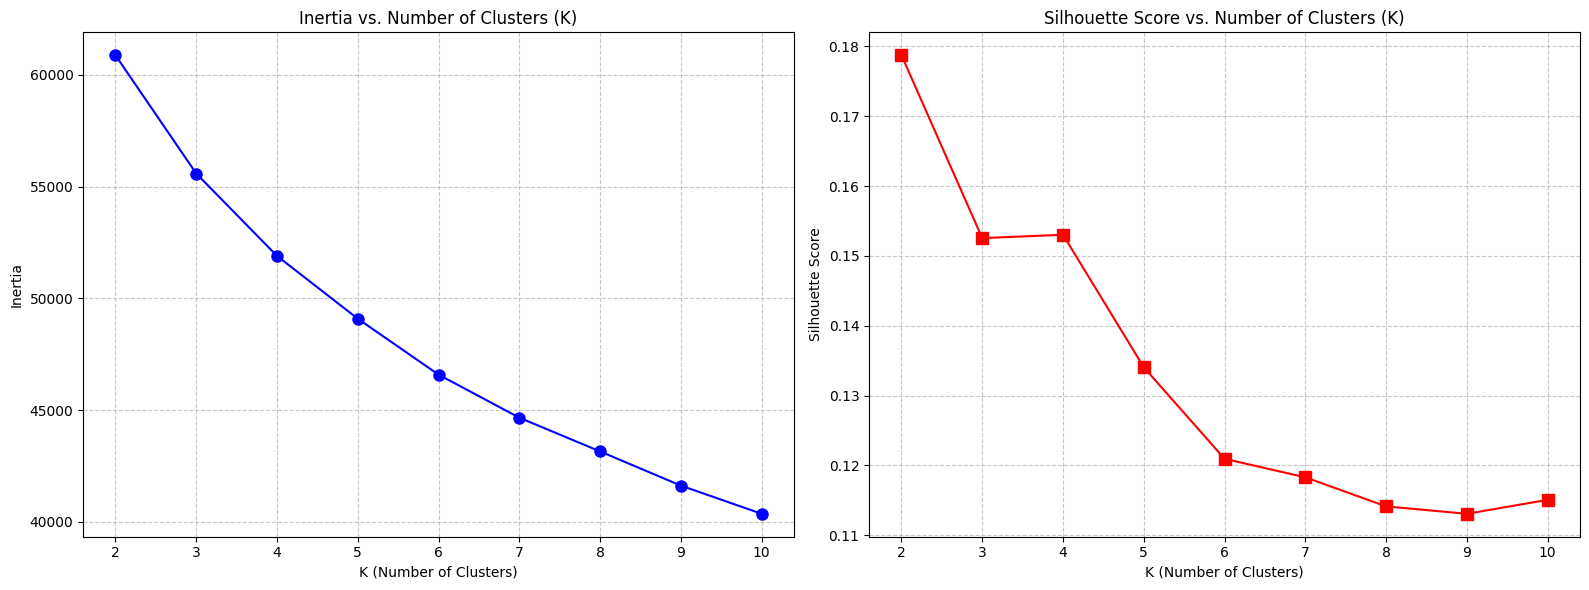

In [19]:
# Create a figure with two separate subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot Inertia vs K
ax1.plot(kmeans_results['K'], kmeans_results['Inertia'], marker='o', linestyle='-', color='blue', markersize=8)
ax1.set_title('Inertia vs. Number of Clusters (K)')
ax1.set_xlabel('K (Number of Clusters)')
ax1.set_ylabel('Inertia')
ax1.grid(True, linestyle='--', alpha=0.7)

# Plot Silhouette Score vs K
ax2.plot(kmeans_results['K'], kmeans_results['Silhouette Score'], marker='s', linestyle='-', color='red', markersize=8)
ax2.set_title('Silhouette Score vs. Number of Clusters (K)')
ax2.set_xlabel('K (Number of Clusters)')
ax2.set_ylabel('Silhouette Score')
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

**Interpretation of Inertia and Silhouette Scores**

The inertia graph shows that the rate of decrease starts to flatten slightly after **K = 4**, indicating a possible elbow point. This suggests that adding more clusters beyond this point provides only limited improvement in compactness. In addition, the silhouette score is highest at **K = 4**, indicating better cluster separation compared with other tested values. Therefore, **K = 4** was selected as the most suitable number of clusters for model building.


In [20]:
# first run of model k=4

kmeans_4 = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

# Fit model and create cluster labels
cluster_labels = kmeans_4.fit_predict(clustering_df)

# Add cluster labels back to original dataframe
customer_df["Cluster"] = cluster_labels

# Check first few rows
customer_df.head()

,CustomerId,Gender,Age,Geo_loc,CreditScore,EstimatedSalary,Balance,NumOfProducts,HasCrCard,Tenure,IsActiveMember,Exited,Cluster
0,15592531,Male,50,France,822,10062.80,0.0,2,1,7,1,0,2
1,15724944,Male,34,France,663,180427.24,0.0,2,1,7,1,0,2
2,15598493,Male,50,France,656,72143.44,0.0,2,1,7,1,0,2
3,15747542,Male,52,France,605,173952.50,0.0,2,1,7,1,0,2
4,15721935,Male,25,France,521,157878.67,0.0,2,1,7,1,0,2


In [21]:
# count of customers in each cluster

customer_df["Cluster"].value_counts().sort_index()

,count
Cluster,
0,2028
1,3548
2,3281
3,1140


In [22]:
# percentage distribution of each clusters

cluster_distribution = (
    customer_df["Cluster"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

cluster_distribution

,proportion
Cluster,
0,20.29
1,35.49
2,32.82
3,11.40


In [23]:
# Analysis of clusters created
# Cluster summary table


cluster_profile = customer_df.groupby("Cluster").agg(
    customer_count=("CustomerId", "count"),
    churn_rate=("Exited", "mean"),
    avg_age=("Age", "mean"),
    avg_credit_score=("CreditScore", "mean"),
    avg_tenure=("Tenure", "mean"),
    avg_balance=("Balance", "mean"),
    avg_salary=("EstimatedSalary", "mean"),
    avg_products=("NumOfProducts", "mean"),
    active_member_rate=("IsActiveMember", "mean")
).reset_index()

# Convert rates to percentages
cluster_profile["churn_rate"] = cluster_profile["churn_rate"] * 100
cluster_profile["active_member_rate"] = cluster_profile["active_member_rate"] * 100

cluster_profile.round(2)

,Cluster,customer_count,churn_rate,avg_age,avg_credit_score,avg_tenure,avg_balance,avg_salary,avg_products,active_member_rate
0,0,2028,19.72,36.82,652.60,4.99,120375.56,102853.36,2.13,50.30
1,1,3548,21.48,36.06,650.15,4.99,120400.95,101072.10,1.00,48.65
2,2,3281,11.64,36.01,649.06,5.11,69.16,99384.02,1.81,49.38
3,3,1140,43.25,59.97,652.40,4.86,81637.04,94168.93,1.31,68.68


**Interpretations and insights from the 4 clusters created**

| Cluster | Key profile                                                 | Suggested segment name                  |
| ------: | ----------------------------------------------------------- | --------------------------------------- |
|       0 | High balance, highest product usage, moderate churn         | **High-Value Multi-Product Customers**  |
|       1 | High balance, single-product customers, moderate-high churn | **High-Value Single-Product Customers** |
|       2 | Almost zero balance, lower churn, moderate product usage    | **Low-Balance Stable Customers**        |
|       3 | Much older customers, highest churn, moderate balance       | **Older High-Risk Customers**           |


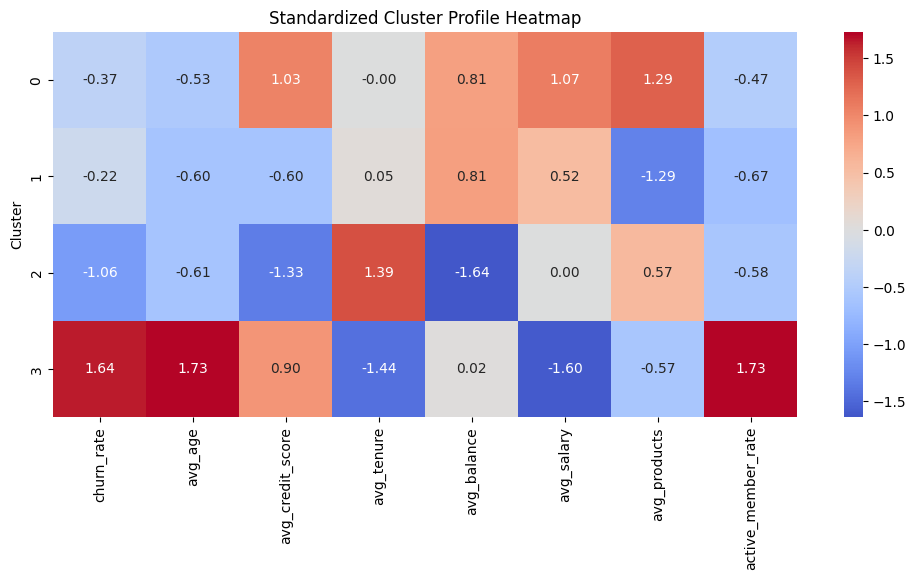

In [24]:
heatmap_cols = [
    "churn_rate",
    "avg_age",
    "avg_credit_score",
    "avg_tenure",
    "avg_balance",
    "avg_salary",
    "avg_products",
    "active_member_rate"
]

profile_scaled = cluster_profile.copy()

scaler = StandardScaler()
profile_scaled[heatmap_cols] = scaler.fit_transform(cluster_profile[heatmap_cols])

plt.figure(figsize=(12, 5))
sns.heatmap(
    profile_scaled.set_index("Cluster")[heatmap_cols],
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Standardized Cluster Profile Heatmap")
plt.show()

Key interpretations


1.   **Cluster 3** is the clearest high-risk segment with highest churn rate, lowest avg salary and lowest avg tenure among all the clusters.
2.   **Cluster 0** is a strong high-value, multi-product segment with high bank balance, salary, healthy product engagement and the lowest churn rate.
3. **Cluster 1** segment shares almost a similar profile to Cluster 0 but differs in product depth aspect where the avg customer is purchasing only a single product.
4. **Cluster 2** the most unique segment with low churn rate, long term tenure and similar salary to Cluster 1 but having the lowest bank balance (69.16) among all the segments.



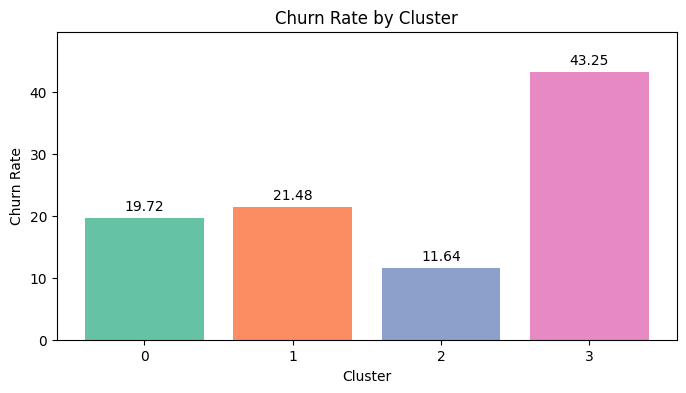

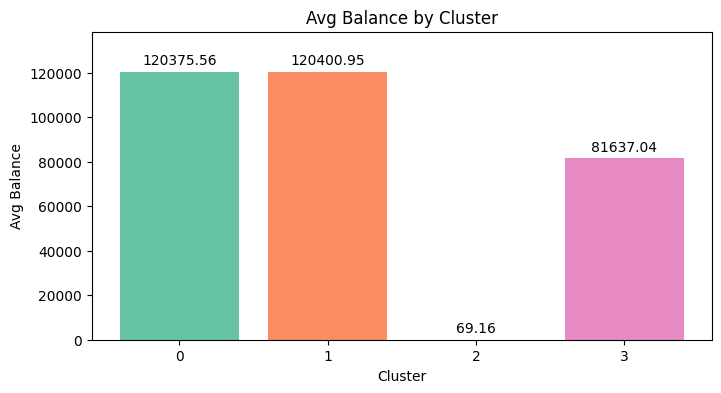

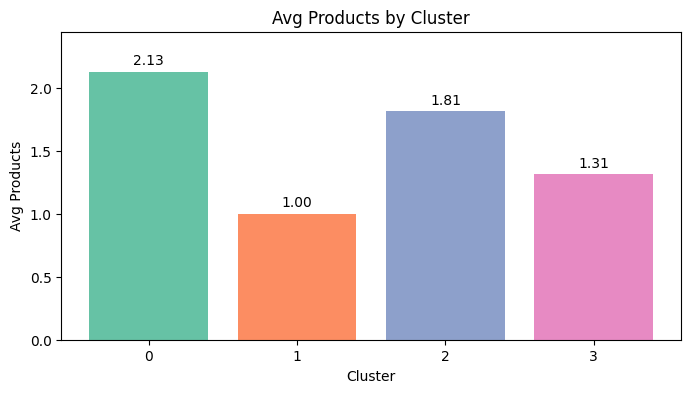

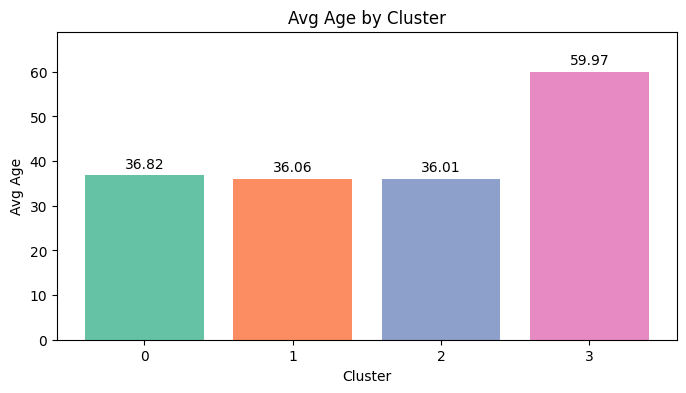

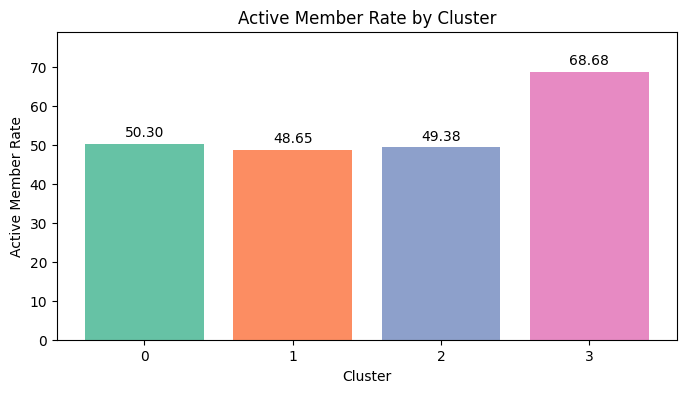

In [25]:
metrics = [
    "churn_rate",
    "avg_balance",
    "avg_products",
    "avg_age",
    "active_member_rate"
]

# Define a distinct color palette for the clusters
cluster_colors = plt.cm.Set2.colors[:len(cluster_profile["Cluster"])]

for metric in metrics:
    plt.figure(figsize=(8, 4))
    ax = plt.gca()

    # Apply the cluster colors to the bars
    bars = ax.bar(
        cluster_profile["Cluster"],
        cluster_profile[metric],
        color=cluster_colors
    )

    # Add values on top of the bars
    ax.bar_label(bars, padding=3, fmt='%.2f')

    plt.title(f"{metric.replace('_', ' ').title()} by Cluster")
    plt.xlabel("Cluster")
    plt.ylabel(metric.replace("_", " ").title())
    plt.xticks(cluster_profile["Cluster"])

    # Add some overhead space for the labels
    plt.ylim(0, cluster_profile[metric].max() * 1.15)

    plt.show()

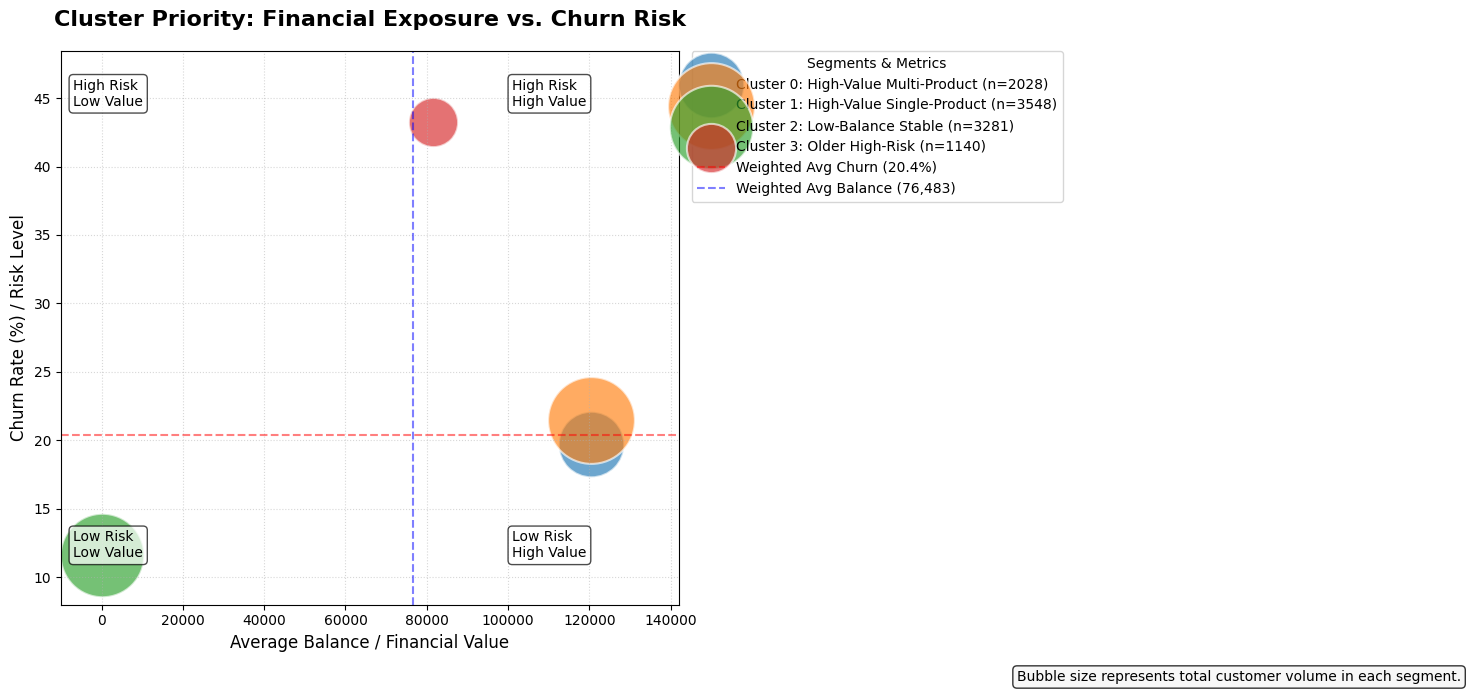

In [26]:
plt.figure(figsize=(14, 7))

# Cluster names
cluster_names = {
    0: "High-Value Multi-Product",
    1: "High-Value Single-Product",
    2: "Low-Balance Stable",
    3: "Older High-Risk"
}

# Fixed colors for consistency
cluster_colors = {
    0: "#1f77b4",
    1: "#ff7f0e",
    2: "#2ca02c",
    3: "#d62728"
}

# Plot each cluster bubble
for _, row in cluster_profile.iterrows():
    cluster_id = int(row["Cluster"])

    plt.scatter(
        row["avg_balance"],
        row["churn_rate"],
        s=row["customer_count"] * 1.1,
        alpha=0.65,
        color=cluster_colors[cluster_id],
        edgecolors="white",
        linewidth=1.5,
        label=f"Cluster {cluster_id}: {cluster_names[cluster_id]} (n={int(row['customer_count'])})"
    )

# Weighted reference lines
avg_churn = np.average(
    cluster_profile["churn_rate"],
    weights=cluster_profile["customer_count"]
)

avg_balance = np.average(
    cluster_profile["avg_balance"],
    weights=cluster_profile["customer_count"]
)

plt.axhline(
    avg_churn,
    color="red",
    linestyle="--",
    alpha=0.5,
    linewidth=1.5,
    label=f"Weighted Avg Churn ({avg_churn:.1f}%)"
)

plt.axvline(
    avg_balance,
    color="blue",
    linestyle="--",
    alpha=0.5,
    linewidth=1.5,
    label=f"Weighted Avg Balance ({avg_balance:,.0f})"
)

# Title and axis labels
plt.title(
    "Cluster Priority: Financial Exposure vs. Churn Risk",
    fontsize=16,
    pad=18,
    weight="bold"
)

plt.xlabel("Average Balance / Financial Value", fontsize=12)
plt.ylabel("Churn Rate (%) / Risk Level", fontsize=12)

# Axis limits
plt.xlim(-10000, cluster_profile["avg_balance"].max() * 1.18)
plt.ylim(8, cluster_profile["churn_rate"].max() * 1.12)

# Grid
plt.grid(True, linestyle=":", alpha=0.5)

# Quadrant labels only
plt.text(
    0.02, 0.95,
    "High Risk\nLow Value",
    transform=plt.gca().transAxes,
    fontsize=10,
    verticalalignment="top",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.7)
)

plt.text(
    0.73, 0.95,
    "High Risk\nHigh Value",
    transform=plt.gca().transAxes,
    fontsize=10,
    verticalalignment="top",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.7)
)

plt.text(
    0.02, 0.08,
    "Low Risk\nLow Value",
    transform=plt.gca().transAxes,
    fontsize=10,
    verticalalignment="bottom",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.7)
)

plt.text(
    0.73, 0.08,
    "Low Risk\nHigh Value",
    transform=plt.gca().transAxes,
    fontsize=10,
    verticalalignment="bottom",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.7)
)

# Legend only, no labels on markers
plt.legend(
    title="Segments & Metrics",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    borderaxespad=0,
    frameon=True
)

# Footnote
plt.figtext(
    0.73,
    0.02,
    "Bubble size represents total customer volume in each segment.",
    fontsize=10,
    ha="left",
    bbox=dict(boxstyle="round", facecolor="whitesmoke", alpha=0.8)
)

plt.tight_layout(rect=[0, 0.04, 0.78, 1])
plt.show()

This map compares each cluster using two business dimensions:

X-axis: Average balance = financial value/exposure
Y-axis: Churn rate = customer risk
Bubble size: Number of customers in the cluster
Dashed red line: Weighted average churn rate, around 20.4%
Dashed blue line: Weighted average balance, around 76,483






**Key Interpretations**

* **Cluster 3: Older High-Risk** is the top priority. It has high churn, around **43.25%**, and above-average balance, around **81,637**.

* **Cluster 1: High-Value Single-Product** is a strong growth opportunity. It has high average balance, around **120,401**, but slightly above-average churn, around **21.48%**.

* **Cluster 0: High-Value Multi-Product** is valuable and relatively stable, with churn around **19.72%** and high average balance, around **120,376**.

* **Cluster 2: Low-Balance Stable** has the lowest churn, around **11.64%**, but almost no average balance.



### Strategic Interpretation of the Cluster Priority Map

This map categorizes our segments into four strategic quadrants based on the intersection of **Financial Exposure (Average Balance)** and **Retention Risk (Churn Rate)**:

1.  **Critical Risk (Top-Right/Top-Center): Cluster 3**
    *   **Profile**: High Churn (~43%) with moderate balances.
    *   **Insight**: This is the most unstable segment. Even though they are active members, their high age and high churn suggest they are leaving the bank at a rapid rate. This requires an immediate retention audit.

2.  **High-Value Growth (Bottom-Right): Clusters 0 & 1**
    *   **Profile**: High Balances.
    *   **Insight**: These clusters represent the 'bank's backbone.' Cluster 0 is healthier due to multi-product usage. Cluster 1 is a prime target for cross-selling to move them into the more stable multi-product profile of Cluster 0.

3.  **Stable Low-Value (Bottom-Left): Cluster 2**
    *   **Profile**: Lowest Churn (~11%) and near-zero balances.
    *   **Insight**: These are loyal but 'dormant' accounts. They aren't leaving, but they aren't generating significant interest income. Strategy should focus on incentivizing deposits.

4.  **The Size Factor**: The bubble size indicates that **Clusters 1 and 2** are our largest populations. While Cluster 3 is high risk, Cluster 1 actually represents a larger total financial risk due to the sheer volume of high-balance customers trending toward churn.

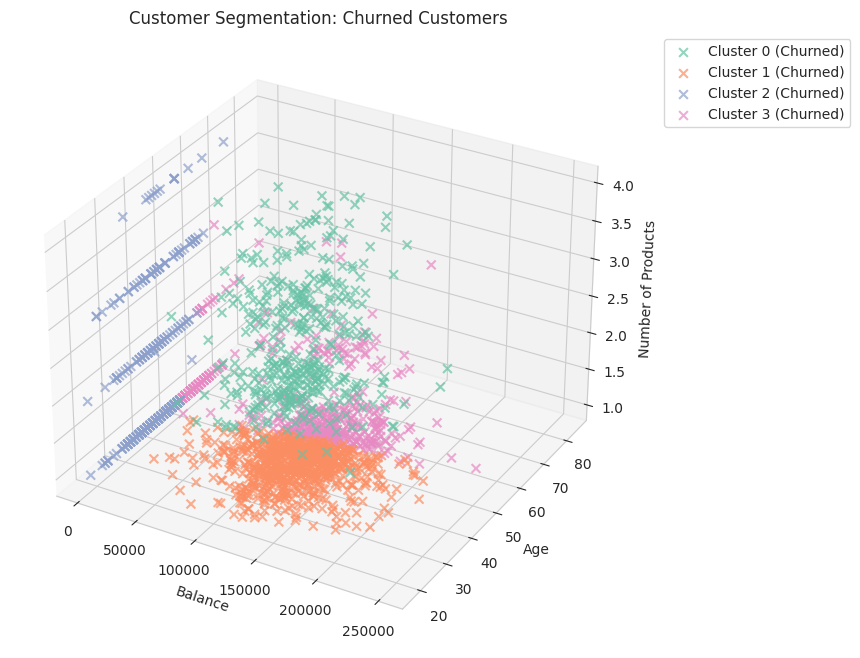

In [27]:
# Fix: Create Churn_Status column before filtering
customer_df['Churn_Status'] = customer_df['Exited'].map({1: 'Churned', 0: 'Retained'})

# Set seaborn style
sns.set_style("whitegrid")

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Map clusters to colors using seaborn palette
clusters = sorted(customer_df['Cluster'].unique())
colors = sns.color_palette("Set2", len(clusters))

# Plot only churned customers for each cluster
for i, cluster in enumerate(clusters):
    cluster_data = customer_df[customer_df['Cluster'] == cluster]

    # Filter for Churned customers only
    subset = cluster_data[cluster_data['Churn_Status'] == "Churned"]

    ax.scatter(
        subset['Balance'],
        subset['Age'],
        subset['NumOfProducts'],
        color=colors[i],
        marker="x",
        label=f"Cluster {cluster} (Churned)",
        alpha=0.7,
        s=40
    )

ax.set_xlabel('Balance')
ax.set_ylabel('Age')
ax.set_zlabel('Number of Products')
ax.set_title('Customer Segmentation: Churned Customers')

# Move legend outside
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

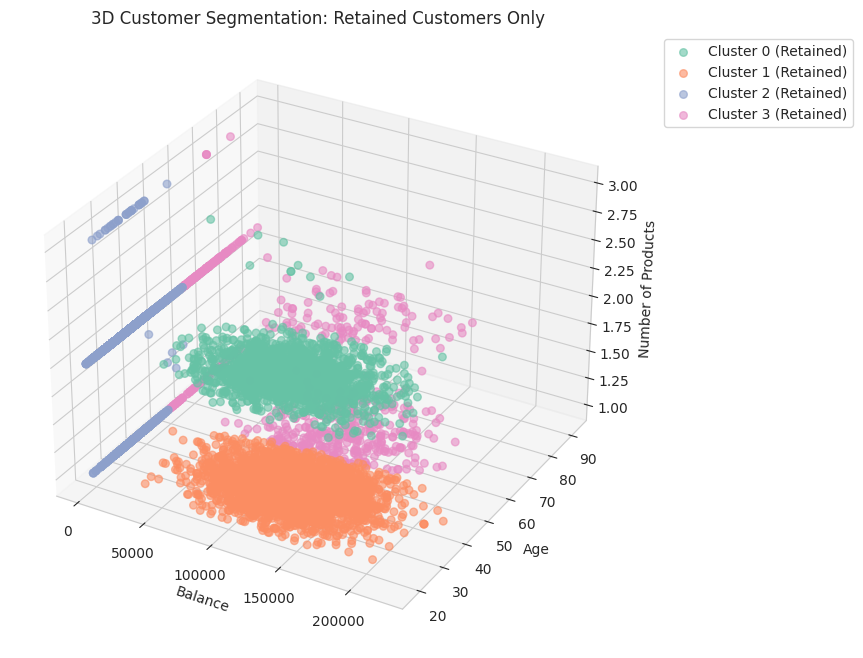

In [28]:
# Ensure Churn_Status exists
customer_df['Churn_Status'] = customer_df['Exited'].map({1: 'Churned', 0: 'Retained'})

# Set seaborn style
sns.set_style("whitegrid")

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Map clusters to colors
clusters = sorted(customer_df['Cluster'].unique())
colors = sns.color_palette("Set2", len(clusters))

# Plot only retained customers for each cluster
for i, cluster in enumerate(clusters):
    cluster_data = customer_df[customer_df['Cluster'] == cluster]

    # Filter for retained customers only
    subset = cluster_data[cluster_data['Churn_Status'] == "Retained"]

    ax.scatter(
        subset['Balance'],
        subset['Age'],
        subset['NumOfProducts'],
        color=colors[i],
        marker="o",
        label=f"Cluster {cluster} (Retained)",
        alpha=0.6,
        s=30
    )

ax.set_xlabel('Balance')
ax.set_ylabel('Age')
ax.set_zlabel('Number of Products')
ax.set_title('3D Customer Segmentation: Retained Customers Only')

# Move legend outside
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

Within Cluster Analysis


1.   Age Group
2.   Gender
3. Geography



In [29]:
# creating age groups

age_bins = [17, 30, 40, 50, 60, 70, customer_df["Age"].max()]
age_labels = ["18-30", "31-40", "41-50", "51-60", "61-70", "71+"]

customer_df["AgeGroup"] = pd.cut(
    customer_df["Age"],
    bins=age_bins,
    labels=age_labels,
    include_lowest=True
)

customer_df[["Age", "AgeGroup"]].head()

,Age,AgeGroup
0,50,41-50
1,34,31-40
2,50,41-50
3,52,51-60
4,25,18-30


In [30]:
customer_df["AgeGroup"].value_counts().sort_index()

,count
AgeGroup,
18-30,1968
31-40,4449
41-50,2319
51-60,797
61-70,331
71+,133


In [31]:
# overall cluster profile by geography

cluster_geo_profile = customer_df.groupby(["Cluster", "Geo_loc"]).agg(
    customer_count=("CustomerId", "count"),
    churn_rate=("Exited", "mean"),
    avg_age=("Age", "mean"),
    avg_balance=("Balance", "mean"),
    avg_salary=("EstimatedSalary", "mean"),
    avg_products=("NumOfProducts", "mean"),
    active_member_rate=("IsActiveMember", "mean")
).reset_index()

# Convert rates to percentages
cluster_geo_profile["churn_rate"] *= 100
cluster_geo_profile["active_member_rate"] *= 100

cluster_geo_profile.round(2)

,Cluster,Geo_loc,customer_count,churn_rate,avg_age,avg_balance,avg_salary,avg_products,active_member_rate
0,0,France,626,18.53,36.38,120873.77,105444.85,2.12,49.84
1,0,Germany,1085,19.35,37.13,119548.02,101552.06,2.13,51.89
2,0,Spain,317,23.34,36.62,122224.12,102189.76,2.11,45.74
3,1,France,1651,13.87,35.53,121100.75,99995.01,1.00,48.52
4,1,Germany,1107,37.67,36.80,120034.03,103167.93,1.00,45.08
5,1,Spain,790,14.68,36.12,119452.62,100386.26,1.00,53.92
6,2,France,2197,11.65,35.99,78.51,99847.74,1.81,49.98
7,2,Spain,1084,11.62,36.04,50.21,98444.16,1.82,48.15
8,3,France,539,38.78,60.41,65966.01,93411.20,1.34,70.32
9,3,Germany,316,59.18,59.24,119222.27,92413.11,1.24,58.54


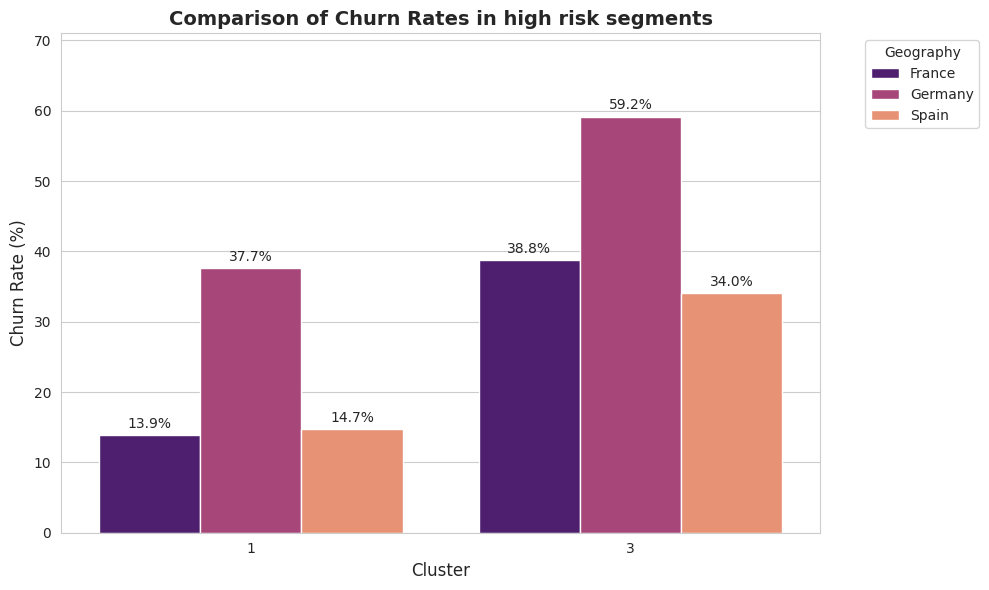

In [32]:
# visualize churn rates in cluster 1 and 3
# Filter the geographical profile for Clusters 1 and 3
filtered_geo = cluster_geo_profile[cluster_geo_profile['Cluster'].isin([1, 3])].copy()

# Set the plot style
sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))

# Create the bar chart
ax = sns.barplot(
    data=filtered_geo,
    x="Cluster",
    y="churn_rate",
    hue="Geo_loc",
    palette="magma"
)

# Add percentage labels on top of bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3)

# Formatting
plt.title("Comparison of Churn Rates in high risk segments", fontsize=14, weight='bold')
plt.xlabel("Cluster", fontsize=12)
plt.ylabel("Churn Rate (%)", fontsize=12)
plt.legend(title="Geography", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.ylim(0, filtered_geo['churn_rate'].max() * 1.2)

plt.tight_layout()
plt.show()

Key Interpretations and findings

1. Cluster 1 (High-Value Single-Product): While this cluster has an overall churn rate of 21%, the risk is heavily concentrated in **Germany**, where it nearly doubles to 37.67%. These are high-balance customers with only one product; in Germany, they are leaving at a much faster rate than in France or Spain.

2. Cluster 3 (Older High-Risk): This is our highest-risk group globally (~43% churn), but again, **Germany** is the primary driver with a massive 59.18% churn rate. Even in France and Spain, the rates are high (34-38%), confirming that the 'Senior' demographic is vulnerable regardless of location, but specifically critical in the German market.

3. **France** as the Volume Leader: France holds the largest share of customers across almost all clusters, particularly in Cluster 2 (Low-Balance Stable) with over 2,100 customers. It serves as the primary base for our most loyal (low-churn) segments.

In summary, while these clusters are high-risk overall, the geographical breakdown reveals that **Germany** is the 'Epicenter' of the churn problem for these specific segments.

In [33]:
# cluster profile by age group

cluster_age_profile = customer_df.groupby(["Cluster", "AgeGroup"]).agg(
    customer_count=("CustomerId", "count"),
    churn_rate=("Exited", "mean"),
    avg_balance=("Balance", "mean"),
    avg_salary=("EstimatedSalary", "mean"),
    avg_products=("NumOfProducts", "mean"),
    active_member_rate=("IsActiveMember", "mean")
).reset_index()

cluster_age_profile["churn_rate"] *= 100
cluster_age_profile["active_member_rate"] *= 100

cluster_age_profile.round(2)

/tmp/ipykernel_27842/1589254211.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_age_profile = customer_df.groupby(["Cluster", "AgeGroup"]).agg(


,Cluster,AgeGroup,customer_count,churn_rate,avg_balance,avg_salary,avg_products,active_member_rate
0,0,18-30,418,7.89,120519.23,99926.95,2.04,49.76
1,0,31-40,999,13.01,120538.67,101646.75,2.07,51.65
2,0,41-50,523,33.65,119540.16,106308.68,2.20,49.14
3,0,51-60,80,66.25,123473.46,110503.97,2.62,46.25
4,0,61-70,8,100.00,116134.74,104035.84,3.12,25.00
5,0,71+,0,NaN,NaN,NaN,NaN,NaN
6,1,18-30,778,10.80,120286.00,99925.64,1.00,53.21
7,1,31-40,1800,15.17,119880.82,101417.70,1.00,49.72
8,1,41-50,955,41.05,120929.97,100725.28,1.00,43.46
9,1,51-60,15,86.67,155097.61,141142.87,1.00,13.33


In [34]:
# Show only segments with more than 500 customers
significant_age_segments = cluster_age_profile[cluster_age_profile['customer_count'] > 500]
significant_age_segments.round(2)

,Cluster,AgeGroup,customer_count,churn_rate,avg_balance,avg_salary,avg_products,active_member_rate
1,0,31-40,999,13.01,120538.67,101646.75,2.07,51.65
2,0,41-50,523,33.65,119540.16,106308.68,2.20,49.14
6,1,18-30,778,10.80,120286.00,99925.64,1.00,53.21
7,1,31-40,1800,15.17,119880.82,101417.70,1.00,49.72
8,1,41-50,955,41.05,120929.97,100725.28,1.00,43.46
12,2,18-30,772,4.02,123.86,102893.15,1.85,49.74
13,2,31-40,1650,8.18,59.24,95740.04,1.79,48.67
14,2,41-50,778,24.04,43.14,104099.59,1.76,48.07
21,3,51-60,622,56.91,85964.28,94796.28,1.22,58.52


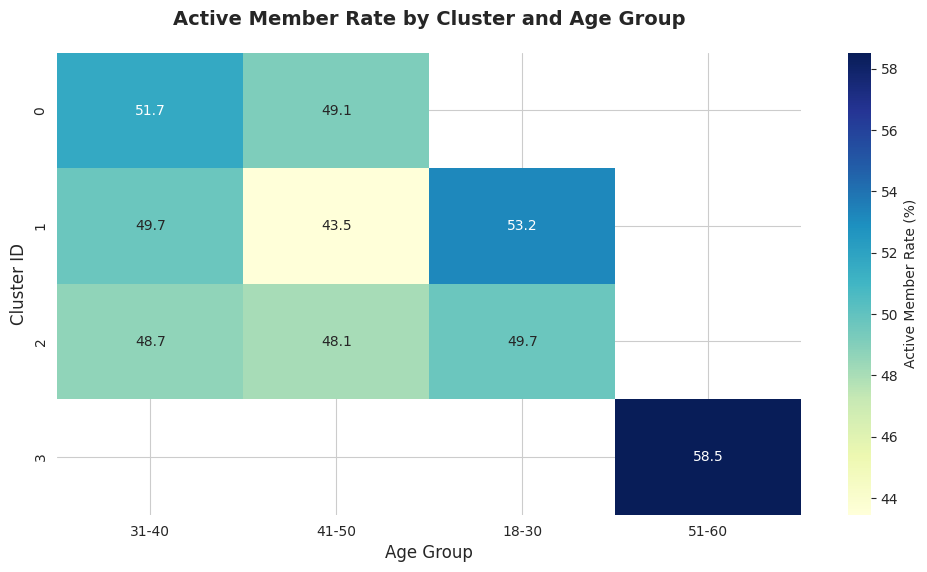

In [35]:
# Pivot the data for the heatmap using the significant segments identified earlier
active_member_pivot = significant_age_segments.pivot(index="Cluster", columns="AgeGroup", values="active_member_rate")

plt.figure(figsize=(12, 6))
sns.heatmap(
    active_member_pivot,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu",
    cbar_kws={'label': 'Active Member Rate (%)'}
)

plt.title("Active Member Rate by Cluster and Age Group", fontsize=14, weight='bold', pad=20)
plt.xlabel("Age Group", fontsize=12)
plt.ylabel("Cluster ID", fontsize=12)
plt.show()

1. **High-Value Young Adults (18-30)**
Cluster 1 & 2: These groups show extremely high loyalty. Cluster 2 (Low-Balance) has the lowest churn rate in the entire dataset at 4.02%, followed by Cluster 1 at 10.80%. This suggests that younger customers are very stable, even if they currently hold low balances.
2. **The Core Multi-Product Base (31-40)**
Cluster 0 & 2: With nearly 2,650 customers in this age bracket, these are our most active 'bread and butter' segments. Churn remains relatively healthy (8-13%), and they maintain high product engagement.

3. **The 41-50 'Risk Surge'**
This is where we see the most significant shift in behavior:

    Cluster 1 (Single-Product): Churn spikes to 41.05%.
    This is a critical insight: middle-aged customers with high balances but only one product are at the highest risk of leaving.
    
    Cluster 0 (Multi-Product): Even with multiple products, churn rises to 33.65%, suggesting that life-stage changes in this decade significantly impact bank loyalty regardless of product depth.

4. **The Senior Danger Zone (51-60)**
Cluster 3: This is the only significant group in the 51+ range with over 600 customers. It carries a massive 56.91% churn rate. Despite being active members, more than half of this high-volume senior segment is exiting, confirming this is the bank's most urgent retention priority.

,Cluster,Gender,customer_count,churn_rate,avg_age,avg_balance,avg_salary,avg_products,active_member_rate
0,0,Female,937,24.55,37.18,119331.56,101674.06,2.16,47.60
1,0,Male,1091,15.58,36.52,121272.18,103866.19,2.09,52.61
2,1,Female,1572,26.08,36.20,119451.07,102376.23,1.00,48.22
3,1,Male,1976,17.81,35.95,121156.62,100034.60,1.00,48.99
4,2,Female,1494,15.39,36.32,90.65,100043.61,1.81,48.80
5,2,Male,1787,8.51,35.74,51.20,98832.58,1.81,49.86
6,3,Female,538,50.00,59.82,81511.13,95136.25,1.31,64.87
7,3,Male,602,37.21,60.10,81749.57,93304.44,1.32,72.09


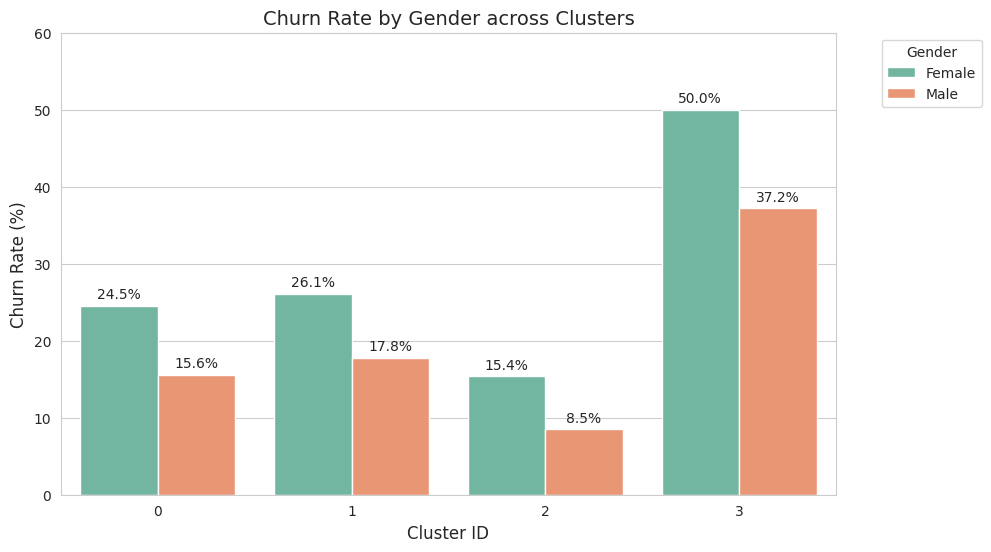

In [36]:
# cluster profile by gender
cluster_gender_profile = customer_df.groupby(["Cluster", "Gender"]).agg(
    customer_count=("CustomerId", "count"),
    churn_rate=("Exited", "mean"),
    avg_age=("Age", "mean"),
    avg_balance=("Balance", "mean"),
    avg_salary=("EstimatedSalary", "mean"),
    avg_products=("NumOfProducts", "mean"),
    active_member_rate=("IsActiveMember", "mean")
).reset_index()

cluster_gender_profile["churn_rate"] *= 100
cluster_gender_profile["active_member_rate"] *= 100

display(cluster_gender_profile.round(2))

# Plot churn_rate for males vs females for all clusters
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

ax = sns.barplot(
    data=cluster_gender_profile,
    x="Cluster",
    y="churn_rate",
    hue="Gender",
    palette="Set2"
)

# Add labels and formatting
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3)

plt.title("Churn Rate by Gender across Clusters", fontsize=14)
plt.xlabel("Cluster ID", fontsize=12)
plt.ylabel("Churn Rate (%)", fontsize=12)
plt.legend(title="Gender", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.ylim(0, cluster_gender_profile["churn_rate"].max() * 1.2)
plt.show()

Key Interpretations and findings

**The Universal Gender Churn Gap**

In every single cluster, female customers exhibit higher churn rates than male customers. This is not restricted to any specific wealth, age bracket or product depth, suggesting a systemic difference in how female customers interact with or perceive the bank's value proposition. Since females represent nearly 45% of the total customer base, this consistent 7-9% churn gap across all segments represents a major leakage point. Retention strategies—such as personalized communication or product bundles—may need to be specifically audited for their appeal and effectiveness among female demographics.

In [37]:
# product Depth Analysis

product_profile = customer_df.groupby(["Cluster", "NumOfProducts"]).agg(
    customer_count=("CustomerId", "count"),
    churn_rate=("Exited", "mean"),
    avg_balance=("Balance", "mean"),
    avg_salary=("EstimatedSalary", "mean")
).reset_index()

product_profile["churn_rate"] *= 100
product_profile.round(2)

,Cluster,NumOfProducts,customer_count,churn_rate,avg_balance,avg_salary
0,0,2,1819,11.05,120357.09,102537.72
1,0,3,163,93.87,120049.70,106761.12
2,0,4,46,100.00,122260.61,101487.65
3,1,1,3548,21.48,120400.95,101072.10
4,2,1,739,31.66,0.00,99194.25
5,2,2,2435,3.00,93.19,99333.48
6,2,3,93,65.59,0.00,99784.85
7,2,4,14,100.00,0.00,115527.96
8,3,1,794,52.02,92687.15,92700.78
9,3,2,336,22.02,56454.81,97266.64


The product_profile reveals a critical 'Product Paradox' that is central to the bank's churn problem:

1. **The 'Multi-Product Trap' (Clusters 0 & 2)**
In segments that are generally stable, there is a sharp 'cliff' at 3 products.

    Cluster 0: Churn is a healthy 11% for 2-product users, but it explodes to 93.8% for those with 3 products and 100% for those with 4.
    The Insight: This suggests that '*product overloading*' is actually a predictor of exit. When a customer reaches 3+ products, they may be consolidating accounts or experiencing service friction that leads to a total break with the bank.

    While the '4-product' 100% churn might be a statistical outlier due to low volume, the '3-product' spike is usually robust enough (across clusters) to conclude that the bank's system or pricing likely penalizes users who try to consolidate all their business into 3+ products.

2. **The 'Single-Product Vulnerability' (Cluster 1)**
Cluster 1 consists entirely of single-product users with high balances. Their churn rate is 21.5%.

    The Insight: Without a second 'anchor' product (like a credit card or secondary savings account), high-wealth customers have very low switching costs. They are 'mobile' wealth that can leave as soon as a competitor offers a better rate.

3. **The 'Anchor Effect' in Cluster 3 (Seniors)**
While Cluster 3 is high-risk, we see a massive reduction in churn for those with two products:

    1 Product: 52.0% Churn
    2 Products: 22.0% Churn
    The Insight: For the senior demographic, adding just one additional product halves the churn risk. This is the most actionable 'quick win' identified: cross-selling a second product to Cluster 3 is mathematically your most effective retention tool.

**Strategic Recommendation**: The goal for all segments should be a 2-product maximum. Pushing customers to 3 or 4 products appears to be counter-productive and strongly correlates with immediate churn.

In [38]:
customer_df['Balance'].describe()

,Balance
count,9997.000000
mean,76482.679807
std,62397.174721
min,0.000000
25%,0.000000
50%,97188.620000
75%,127642.440000
max,250898.090000


In [39]:
# creating balance groups

customer_df["BalanceBand"] = pd.cut(
    customer_df["Balance"],
    bins=[-0.01, 0, 50000, 100000, 150000, np.inf],
    labels=[
        "Zero Balance",
        "Low Balance",
        "Medium Balance",
        "High Balance",
        "Very High Balance"
    ],
    include_lowest=True
)

In [40]:
customer_df["BalanceBand"].value_counts().sort_index()

,count
BalanceBand,
Zero Balance,3616
Low Balance,75
Medium Balance,1509
High Balance,3828
Very High Balance,969


In [41]:
# Analyzing churn risk by balance band cluster

balance_band_profile = customer_df.groupby(["Cluster", "BalanceBand"]).agg(
    customer_count=("CustomerId", "count"),
    churn_rate=("Exited", "mean"),
    active_member_rate=("IsActiveMember", "mean")
).reset_index()

balance_band_profile["churn_rate"] *= 100
balance_band_profile["active_member_rate"] *= 100

balance_band_profile.round(2)

/tmp/ipykernel_27842/1190459448.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  balance_band_profile = customer_df.groupby(["Cluster", "BalanceBand"]).agg(


,Cluster,BalanceBand,customer_count,churn_rate,active_member_rate
0,0,Zero Balance,0,NaN,NaN
1,0,Low Balance,16,25.00,56.25
2,0,Medium Balance,489,16.16,48.67
3,0,High Balance,1196,21.15,51.00
4,0,Very High Balance,327,19.57,49.85
5,1,Zero Balance,0,NaN,NaN
6,1,Low Balance,40,30.00,57.50
7,1,Medium Balance,809,16.69,51.17
8,1,High Balance,2153,23.27,47.98
9,1,Very High Balance,546,20.88,46.89


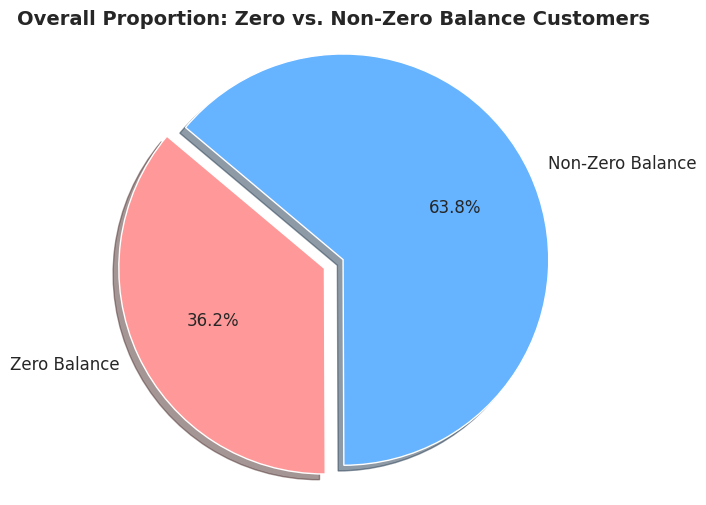

Total Customers: 9997
Zero Balance: 3616 (36.2%)
Non-Zero Balance: 6381 (63.8%)


In [42]:
# Calculate counts
zero_balance_count = (customer_df['Balance'] == 0).sum()
non_zero_balance_count = (customer_df['Balance'] > 0).sum()
total = len(customer_df)

# Prepare data for plotting
labels = ['Zero Balance', 'Non-Zero Balance']
sizes = [zero_balance_count, non_zero_balance_count]
colors = ['#ff9999','#66b3ff']
explode = (0.1, 0)  # offset the zero balance slice

plt.figure(figsize=(8, 6))
plt.pie(
    sizes,
    explode=explode,
    labels=labels,
    colors=colors,
    autopct='%1.1f%%',
    shadow=True,
    startangle=140,
    textprops={'fontsize': 12}
)

plt.title('Overall Proportion: Zero vs. Non-Zero Balance Customers', fontsize=14, fontweight='bold')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

# Display raw counts for clarity
print(f"Total Customers: {total}")
print(f"Zero Balance: {zero_balance_count} ({zero_balance_count/total*100:.1f}%)")
print(f"Non-Zero Balance: {non_zero_balance_count} ({non_zero_balance_count/total*100:.1f}%)")

**Key Interpretations and insights**

1. **The Zero-Balance Anchor (Cluster 2)**:

    Volume: Approximately 36.2% (3,616) of all customers hold a zero balance.
    Concentration: Almost the entirety of these customers are located in Cluster 2.
    Insight: Despite having no funds in their accounts, these customers are surprisingly loyal, with the lowest churn rate (~11.6%) in the dataset. They likely use the bank for non-savings purposes (e.g., as a secondary transactional account).

2. **The 'Low Balance' Danger Zone**
Across all clusters, the 'Low Balance' (1 - 50k) band consistently shows higher churn than the 'Medium' or 'High' bands. For example, in Cluster 1, Low Balance churn is 30.0% vs. 16.7% for Medium Balance. This suggests that customers with small 'dust' balances are the most likely to fully exit the bank.

3. **Medium Balance (Clusters 0 & 1)**: These have the lowest churn among funded accounts (~16%).
High & Very High Balance (Clusters 0 & 1): Churn actually increases to 20-23% in these top tiers.
This suggests that high-balance customers are often more 'mobile' and sensitive to competitor offers, meaning wealth does not automatically equal loyalty.

4. Strategic Recommendation:

    Priority should be placed on migrating 'Low Balance' customers to 'Medium Balance' tiers and investigating why 'Very High Balance' customers show higher attrition than the middle tier. Also concerted eforts need to be made to ensure that thet 'Zero Value customers' start retaining some kind of amount into their accounts.

/tmp/ipykernel_27842/1240309320.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


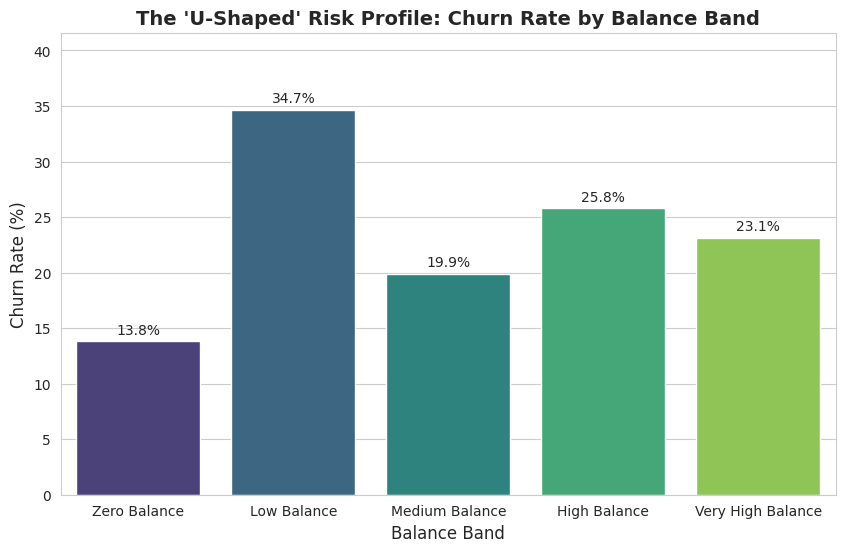

In [43]:
# Aggregate churn rate by balance band across the whole dataset
overall_balance_risk = customer_df.groupby("BalanceBand", observed=True)["Exited"].mean().reset_index()
overall_balance_risk["churn_rate"] = overall_balance_risk["Exited"] * 100

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# Create bar plot
ax = sns.barplot(
    data=overall_balance_risk,
    x="BalanceBand",
    y="churn_rate",
    palette="viridis"
)

# Add percentage labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3)

plt.title("The 'U-Shaped' Risk Profile: Churn Rate by Balance Band", fontsize=14, weight='bold')
plt.ylabel("Churn Rate (%)", fontsize=12)
plt.xlabel("Balance Band", fontsize=12)
plt.ylim(0, overall_balance_risk['churn_rate'].max() * 1.2)
plt.show()

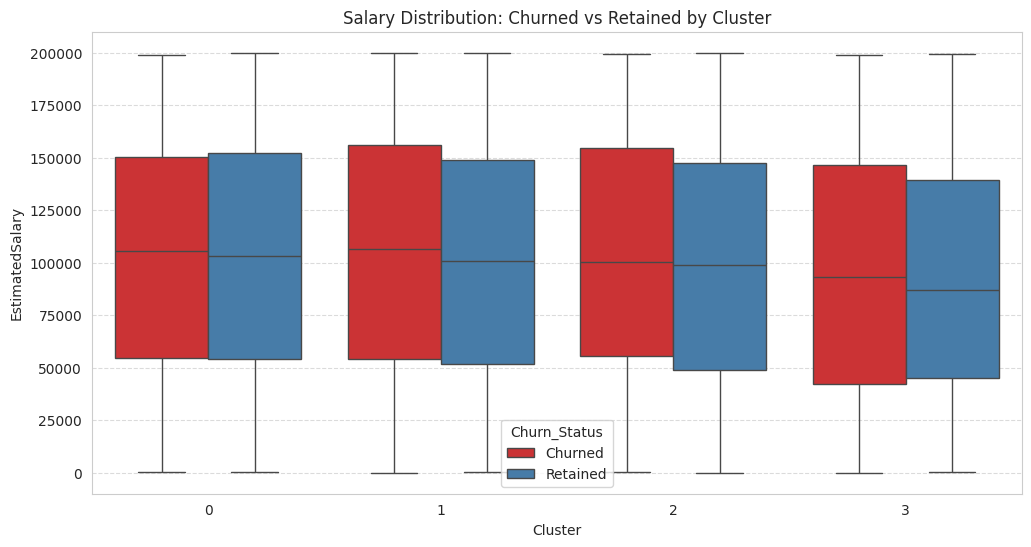

In [44]:
# 2. Salary Distribution vs Churn across Clusters
plt.figure(figsize=(12, 6))
sns.boxplot(data=customer_df, x='Cluster', y='EstimatedSalary', hue='Churn_Status', palette='Set1')
plt.title('Salary Distribution: Churned vs Retained by Cluster')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

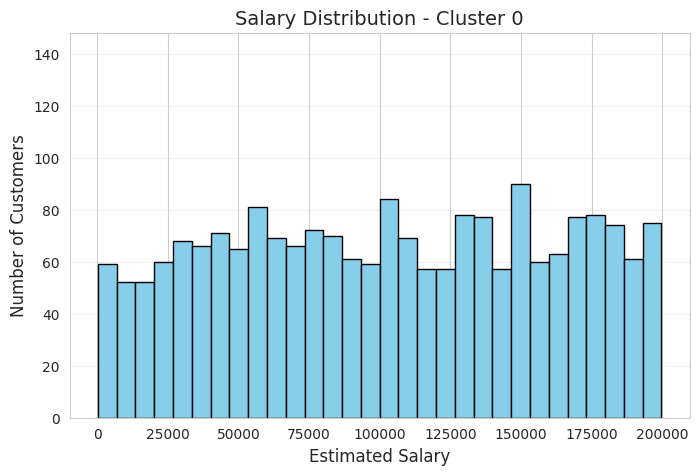

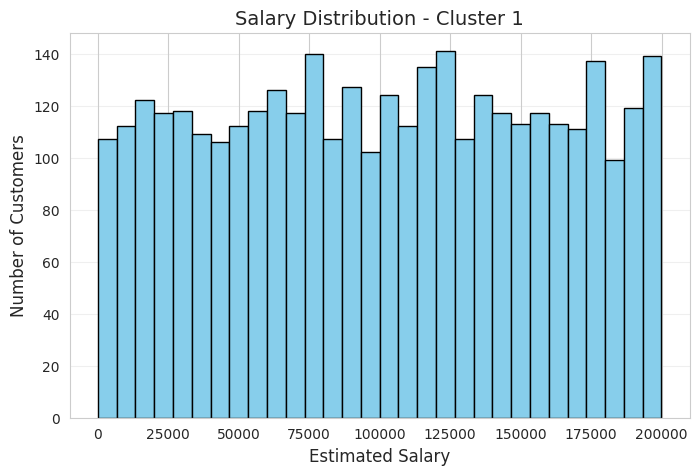

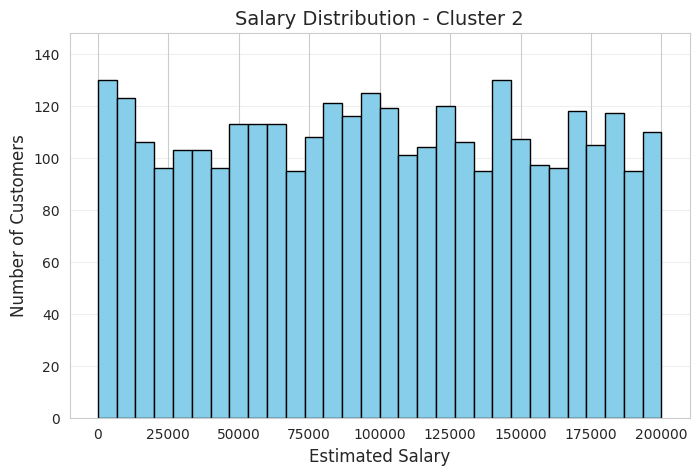

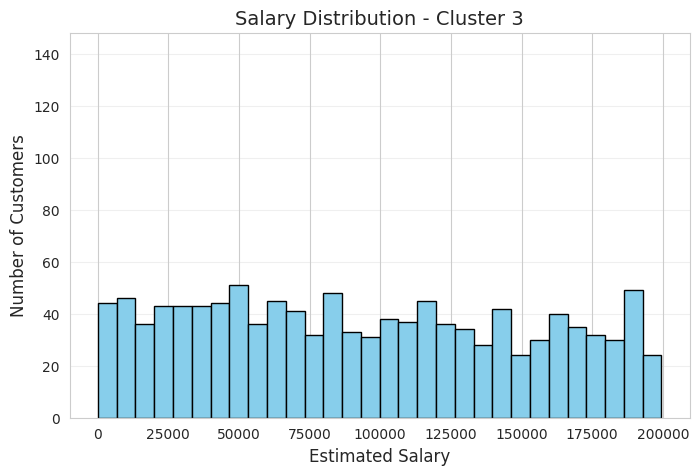

In [45]:
clusters = sorted(customer_df["Cluster"].unique())

# First, determine the maximum count across all clusters for a shared y-axis
max_y = 0
for cluster in clusters:
    counts, _ = np.histogram(customer_df[customer_df["Cluster"] == cluster]["EstimatedSalary"], bins=30)
    max_y = max(max_y, counts.max())

# Buffer for the y-axis limit
max_y = max_y * 1.05

# Plotting salary distribution with synchronized y-axis
for cluster in clusters:
    data = customer_df[customer_df["Cluster"] == cluster]["EstimatedSalary"]

    plt.figure(figsize=(8, 5))
    plt.hist(data, bins=30, color='skyblue', edgecolor="black")
    plt.title(f"Salary Distribution - Cluster {cluster}", fontsize=14)
    plt.xlabel("Estimated Salary", fontsize=12)
    plt.ylabel("Number of Customers", fontsize=12)
    plt.ylim(0, max_y)
    plt.grid(axis="y", alpha=0.3)
    plt.show()

In [46]:
# Define the credit score bins and labels
# Bins must have one more value than labels.
# We extend the range to cover the actual min (350) and max (850) found in the data.
bins = [300, 500, 650, 750, 850]
labels = ["Poor", "Fair", "Good", "Very Good"]

# Permanently adding the credit score band to the dataset
customer_df["CreditScoreBand"] = pd.cut(
    customer_df["CreditScore"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

# Create a cross-tabulation table of Clusters and Credit Score Bands
cluster_credit_summary = pd.crosstab(
    customer_df["Cluster"],
    customer_df["CreditScoreBand"],
    normalize='index'
).mul(100).round(2)

print("Percentage Distribution of Credit Score Bands per Cluster:")
display(cluster_credit_summary)

Percentage Distribution of Credit Score Bands per Cluster:


CreditScoreBand,Poor,Fair,Good,Very Good
Cluster,,,,
0,6.66,42.31,33.88,17.16
1,6.45,42.56,35.46,15.53
2,6.19,43.98,34.59,15.24
3,6.67,42.19,33.68,17.46


In every Cluster barring 3, churn rate improves as the credit score increases, with cluster 2  being a strong example (improvement by 50%), Cluster 3 follows similar pattern till 'Good' band and after that shows a sharp increase for the 'very good' band.

1. **Inverse Correlation (Retention Driver)**

    In Clusters 0, 1, and 2, we see a clear trend where higher credit scores lead to lower churn. For example, in Cluster 2 (Low-Balance Stable), customers with 'Very Good' scores have a churn rate of just 10%, a 50% improvement compared to those in the 'Poor' band (15.27%).

2. **Cluster 3 Vulnerability**

    Regardless of credit score, Cluster 3 (Older High-Risk) remains the most volatile. Even their 'safest' group (Good scores) churns at 37.76%, which is significantly higher than the highest risk groups in any other cluster.

3. **Cluster 1 sensitivity**


    While other clusters see churn drop as scores improve, Cluster 3 shows a sharp increase in churn for the 'Very Good' band (46.73%) compared to the 'Good' band (37.76%). This suggests that for senior customers, high creditworthiness actually correlates with higher mobility or sensitivity to competitor offers.

## Final Strategic Insights & Recommendations

### 1. Cluster-Specific Strategies

*   **Cluster 3 (Older High-Risk): The Immediate Priority**
    *   **Insight:** This segment has the highest churn rate (~43%), which spikes to nearly 60% in Germany. However, seniors with 2 products have half the churn risk of those with only 1.
   

*   **Cluster 1 (High-Value Single-Product): The Growth Engine**
    *   **Insight:** These customers hold significant wealth (~120k balance) but are highly 'mobile' and prone to switching due to low engagement (only 1 product).
    

*   **Cluster 0 (High-Value Multi-Product): The Gold Standard**
    *   **Insight:** This is your most stable high-value segment. Churn is low, but there is a 'Multi-Product Trap' where moving to 3+ products leads to near-certain exit.
   

*   **Cluster 2 (Low-Balance Stable): The Hidden Asset**
    *   **Insight:** Despite near-zero balances, these are your most loyal customers (11.6% churn). They are likely using the bank for specific transactional needs.
    

### 2. Overall Business Recommendations

*   **The German Market Audit:** Germany consistently shows much higher churn rates in high-risk segments than France or Spain. Conduct a local market analysis to see if competitor pricing or regional service gaps are driving this.

*   **Gender-Specific Retention:** Female customers churn at a 7-9% higher rate across all clusters. The bank should audit its communication style and value propositions to ensure they are equally resonant with female demographics.

*   **The 2-Product 'Sweet Spot':** Our analysis shows that 2 products is the ideal engagement level. Churn risk is high at 1 product (low switching costs) and catastrophic at 3+ products (potential service friction). Marketing should focus strictly on moving customers to exactly 2 products.

*   **Active Member Re-engagement:** While Cluster 3 are 'Active Members,' they still leave. This suggests 'Active' status is a lagging indicator for seniors. Use balance-drop alerts as a more proactive early warning system for this group.

## Proposed Product & Service Catalog by Segment

Drawing from real-world banking strategies, here are specific offerings tailored to the risk and value profiles of our clusters:

### **1. Cluster 0: High-Value Multi-Product (The VIPs)**
*   **Proposed Service:** *Priority / Private Banking.*
*   **Specific Products:**
    *   **Wealth Management Concierge:** Since they are stable and high-balance, offer a dedicated advisor to manage their portfolio rather than selling more retail products.
    *   **Family Bundles:** Offer 'Junior' accounts for their children with zero fees, ensuring long-term multi-generational retention without increasing the parent's product count past the 'Multi-Product Trap' threshold.

### **2. Cluster 1: High-Value Single-Product (The Flight-Risk Wealthy)**
*   **Proposed Service:** *Relationship Deepening Program.*
*   **Specific Products:**
    *   **High-Yield 'Anchor' Savings:** Offer a preferential rate on a secondary savings account that requires a 12-month commitment to increase switching costs.
    *   **Premium Credit Cards:** A 'Gold' or 'Platinum' card with travel insurance and lounge access. This acts as a 'daily use' product that integrates the bank into their lifestyle.

### **3. Cluster 2: Low-Balance Stable (The Loyalists)**
*   **Proposed Service:** *Financial Inclusion & Growth Path.*
*   **Specific Products:**
    *   **Automated 'Round-Up' Savings:** A feature that rounds up every transaction to the nearest dollar and puts the change into a savings account. This helps build balances for the 3,600+ customers currently at zero balance.
    *   **Micro-Investment Platforms:** Low-entry barrier SIPs (Systematic Investment Plans) starting at $10/month to transition them from transactional users to asset-holding customers.

### **4. Cluster 3: Older High-Risk (The Senior Retention Priority)**
*   **Proposed Service:** *Legacy & Retirement Security.*
*   **Specific Products:**
    *   **Estate Planning & Will Services:** Offering these as a 'free' benefit for maintaining a 2-product relationship can be a powerful emotional anchor for the 51-60 and 61+ age groups.
    *   **Fixed-Term Senior Deposits:** Higher interest rates for seniors that are 'locked in' for 2-3 years, specifically targeting the high-churn German market to reduce immediate mobility.
    *   **Health Insurance Cross-Sell:** Partner with insurers to offer discounted health coverage, providing a high-value second product that seniors are less likely to cancel.